# CodeAlpha Task 2: Unemployment Analysis with Python


| Internship Details | Information |
|---|---|
| **Intern:** | Cephas Adams Kumah |
| **Program:** | Data Science Internship | 
| **Organization:** | CodeAlpha |

**Objective:** Analyze unemployment data in India to understand unemployment patterns, regional differences, and the impact of COVID-19 on the labour market.

**Task:** Task 2 — Unemployment Analysis with Python

The analysis focuses on:

- Unemployment trends over time
- Rural and urban unemployment patterns
- Regional differences in unemployment rates
- The impact of COVID-19 on unemployment
- Changes in estimated employment levels
- Labour force participation patterns
- Monthly unemployment patterns

The project uses Python for data cleaning, exploratory data analysis, visualization, and interpretation of unemployment trends.

This notebook covers data loading, data cleaning, exploratory data analysis, trend analysis, COVID-19 impact analysis, regional comparison, labour participation analysis, policy insights, and conclusions.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")   

                    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## 2. Load Dataset

In [2]:
df = pd.read_csv("unemployment in india.csv")
df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 3. Data Understanding

In [4]:
df.shape

(768, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [7]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [8]:
print("Duplicates:")
print(df.duplicated().sum())

Duplicates:
27


## 4. Data Cleaning

In [9]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [10]:
# Remove rows containing missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Reset the index
df = df.reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Cleaned dataset shape: (740, 7)

Missing values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

Duplicate rows: 0


In [11]:
# Convert Date to datetime format
df["Date"] = pd.to_datetime(
    df["Date"].str.strip(),
    dayfirst=True,
    errors="coerce"
)

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2019-05-31 00:00:00
Latest date: 2020-06-30 00:00:00


In [12]:
df["Date"].isnull().sum()

np.int64(0)

In [13]:
# clean text columns

df["Region"] = df["Region"].str.strip()
df["Area"] = df["Area"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [14]:
# create useful date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Year_Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September,2019-09


In [15]:
# confirm cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Year                                     740 non-null    int32         
 8   Month                                    740 non-null    int32         
 9   Month_Name                               74

In [17]:
df.describe(include="all")

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Year_Month
count,740,740,740,740.000000,7.400000e+02,740.000000,740,740.000000,740.000000,740,740
unique,28,NaN,1,NaN,NaN,NaN,2,NaN,NaN,12,14
top,Andhra Pradesh,NaN,Monthly,NaN,NaN,NaN,Urban,NaN,NaN,May,2019-10
freq,28,NaN,740,NaN,NaN,NaN,381,NaN,NaN,105,55
mean,NaN,2019-12-12 18:36:58.378378496,NaN,11.787946,7.204460e+06,42.630122,NaN,2019.418919,6.390541,NaN,NaN
min,NaN,2019-05-31 00:00:00,NaN,0.000000,4.942000e+04,13.330000,NaN,2019.000000,1.000000,NaN,NaN
25%,NaN,2019-08-31 00:00:00,NaN,4.657500,1.190404e+06,38.062500,NaN,2019.000000,4.000000,NaN,NaN
50%,NaN,2019-11-30 00:00:00,NaN,8.350000,4.744178e+06,41.160000,NaN,2019.000000,6.000000,NaN,NaN
75%,NaN,2020-03-31 00:00:00,NaN,15.887500,1.127549e+07,45.505000,NaN,2020.000000,9.000000,NaN,NaN
max,NaN,2020-06-30 00:00:00,NaN,76.740000,4.577751e+07,72.570000,NaN,2020.000000,12.000000,NaN,NaN


## 5. Unemployment by Area

In [18]:
area_summary = (
    df.groupby("Area")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
    .round(2)
)

area_summary

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Area,,,
Rural,10.32,10192852.57,44.46
Urban,13.17,4388625.58,40.90


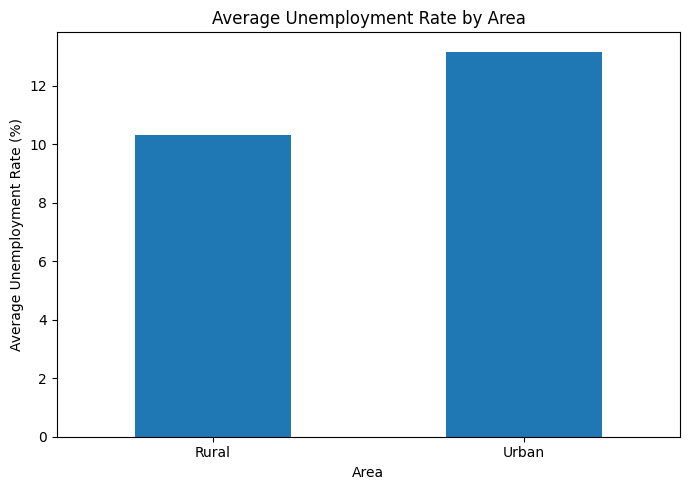

In [19]:
# create a chart
import matplotlib.pyplot as plt

area_unemployment = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(7, 5))
area_unemployment.plot(kind="bar")

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Overall Unemployment Trend in India

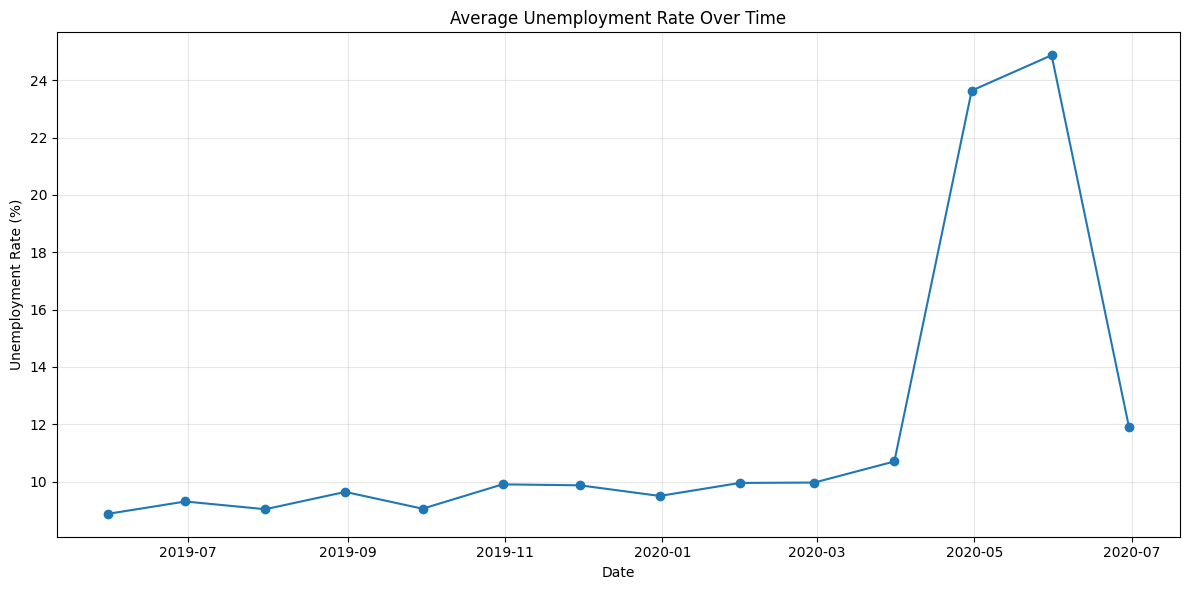

In [20]:
monthly_trend = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_trend["Date"],
    monthly_trend["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Rural vs Urban Analysis

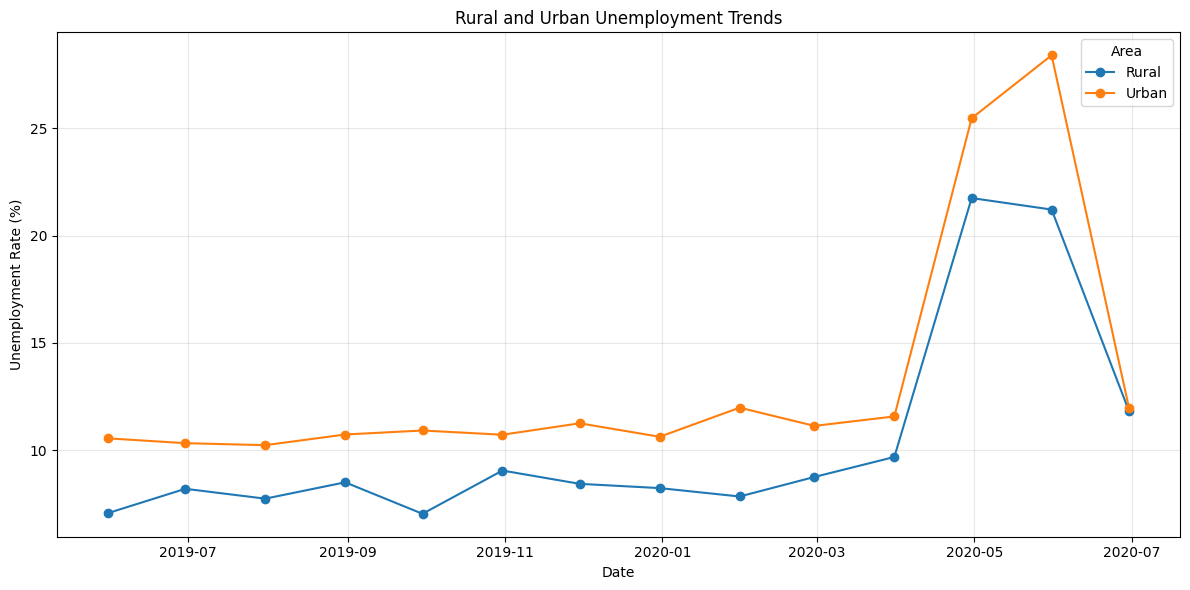

In [21]:
area_trend = (
    df.groupby(["Date", "Area"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for area in area_trend["Area"].unique():
    area_data = area_trend[area_trend["Area"] == area]

    plt.plot(
        area_data["Date"],
        area_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=area
    )

plt.title("Rural and Urban Unemployment Trends")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend(title="Area")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Covid-19 Impact

In [22]:
covid_start = pd.Timestamp("2020-03-01")

df["Period"] = df["Date"].apply(
    lambda date: "Pre-COVID" if date < covid_start else "COVID Period"
)

covid_summary = (
    df.groupby("Period")[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ]
    .mean()
    .round(2)
)

covid_summary

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Period,,,
COVID Period,17.77,6517203.34,39.33
Pre-COVID,9.51,7466027.87,43.89


In [23]:
# Calculate the change 
pre_covid_rate = df.loc[
    df["Period"] == "Pre-COVID",
    "Estimated Unemployment Rate (%)"
].mean()

covid_rate = df.loc[
    df["Period"] == "COVID Period",
    "Estimated Unemployment Rate (%)"
].mean()

percentage_point_change = covid_rate - pre_covid_rate

print(f"Average pre-COVID unemployment rate: {pre_covid_rate:.2f}%")
print(f"Average COVID-period unemployment rate: {covid_rate:.2f}%")
print(f"Change: {percentage_point_change:.2f} percentage points")

Average pre-COVID unemployment rate: 9.51%
Average COVID-period unemployment rate: 17.77%
Change: 8.26 percentage points


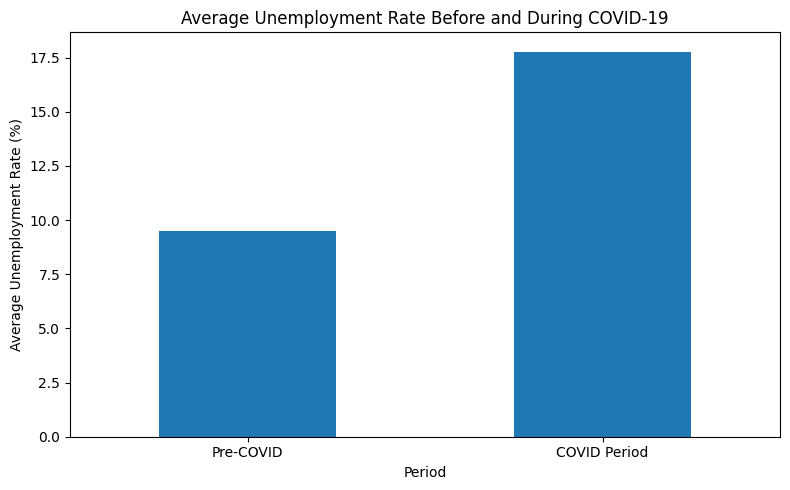

In [24]:
#Create a comparsion chart
covid_rates = (
    df.groupby("Period")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(["Pre-COVID", "COVID Period"])
)

plt.figure(figsize=(8, 5))
covid_rates.plot(kind="bar")

plt.title("Average Unemployment Rate Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Regional Unemployment Analysis

In [25]:
## Identify states with highest unemployment rates
state_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

state_unemployment.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

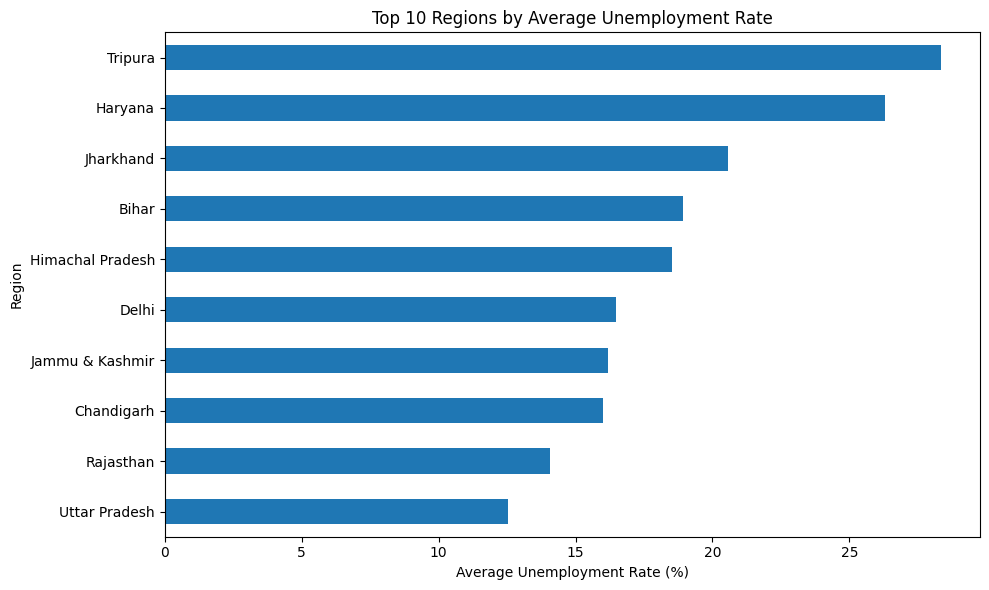

In [26]:
plt.figure(figsize=(10, 6))

state_unemployment.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [28]:
#Identify Regions Most Affected During Covid_19¶
covid_region = (
    df[df["Period"] == "COVID Period"]
    .groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

covid_region.head(10)

Region
Puducherry       38.95500
Jharkhand        36.34875
Haryana          34.65250
Bihar            31.63125
Tripura          26.70250
Tamil Nadu       25.40375
Delhi            22.15750
Kerala           17.95250
Uttar Pradesh    17.38250
Rajasthan        17.31125
Name: Estimated Unemployment Rate (%), dtype: float64

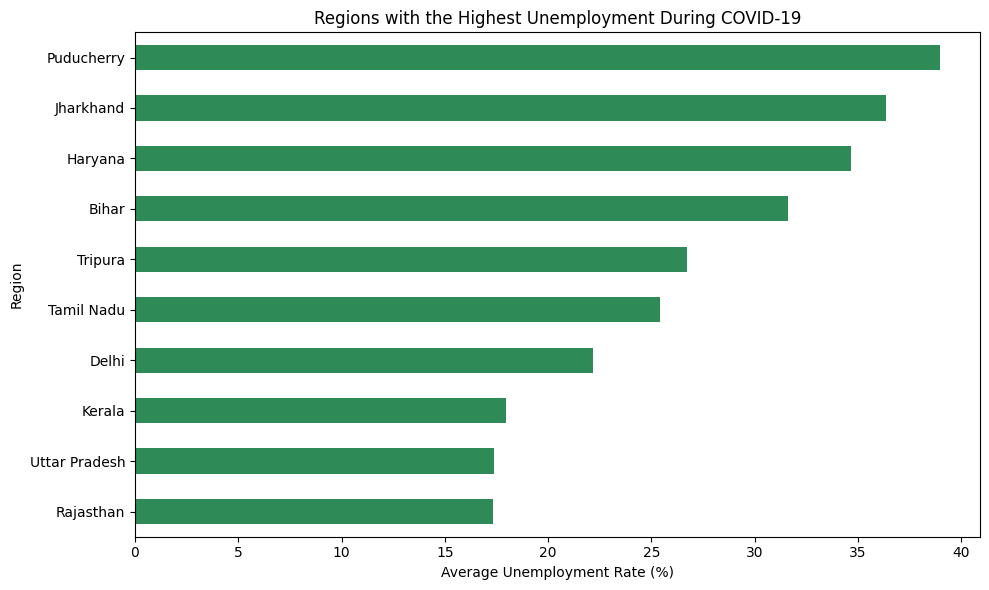

In [33]:
plt.figure(figsize=(10, 6))

covid_region.head(10).sort_values().plot(kind="barh", color='seagreen')

plt.title("Regions with the Highest Unemployment During COVID-19")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 10. Labour Participation Analysis

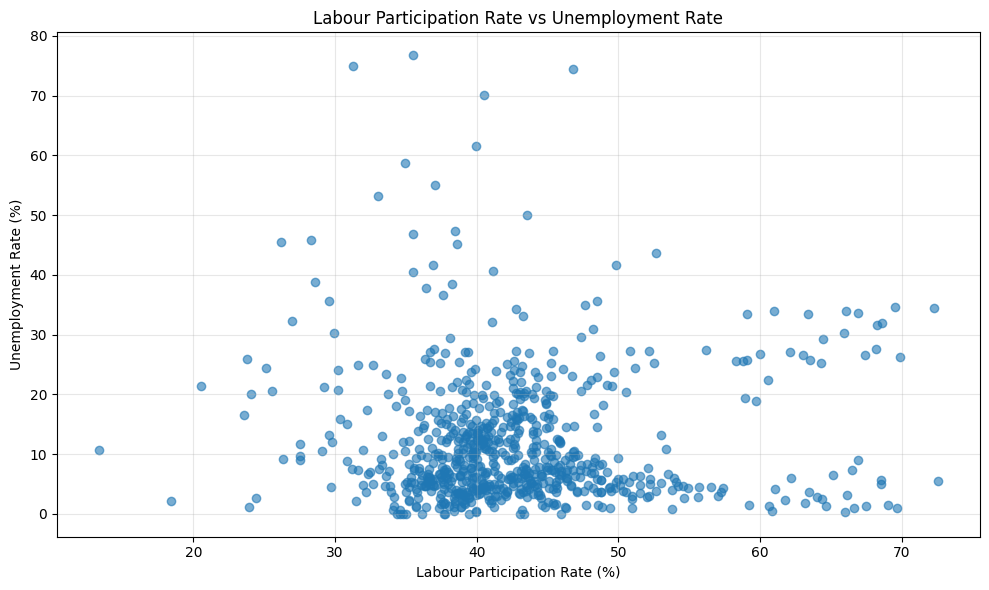

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Estimated Labour Participation Rate (%)"],
    df["Estimated Unemployment Rate (%)"],
    alpha=0.6
)

plt.title("Labour Participation Rate vs Unemployment Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

In [31]:
# Calculate correlation
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


## 12. Monthly Pattern Analysis

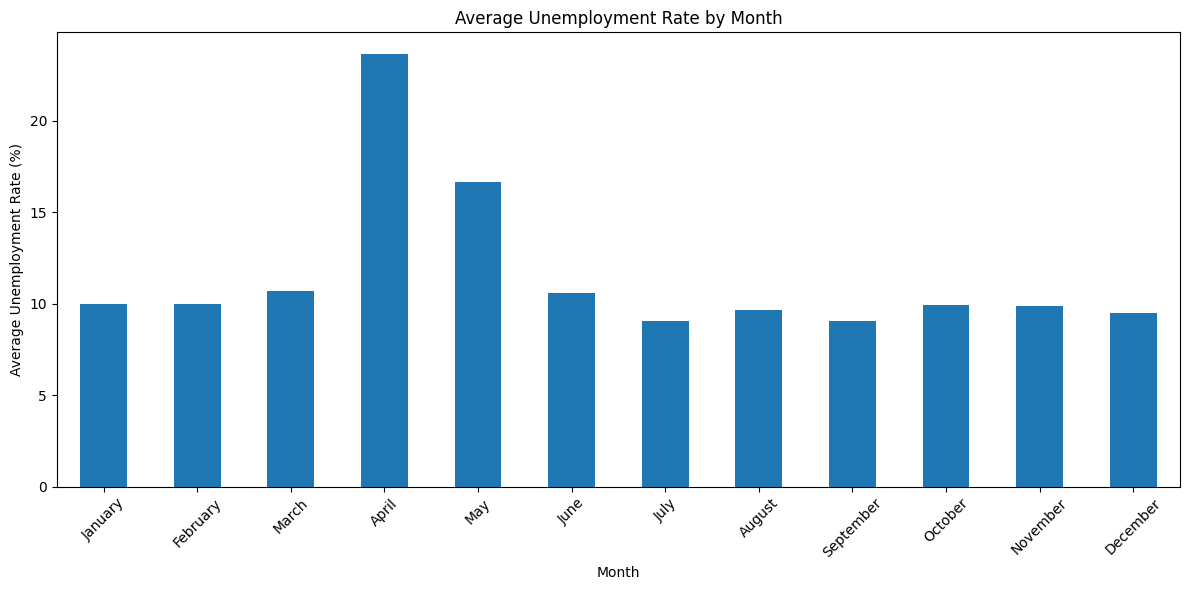

In [32]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_pattern = (
    df.groupby("Month_Name")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(month_order)
    .dropna()
)

plt.figure(figsize=(12, 6))

monthly_pattern.plot(kind="bar")

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Identify highest and lowest unemployment months
highest_month = monthly_pattern.idxmax()
highest_rate = monthly_pattern.max()

lowest_month = monthly_pattern.idxmin()
lowest_rate = monthly_pattern.min()

print(f"Highest average unemployment month: {highest_month} ({highest_rate:.2f}%)")
print(f"Lowest average unemployment month: {lowest_month} ({lowest_rate:.2f}%)")

Highest average unemployment month: April (23.64%)
Lowest average unemployment month: July (9.03%)


## 13. Employment Before and During COVID-19

Period
Pre-COVID       7.466028e+06
COVID Period    6.517203e+06
Name: Estimated Employed, dtype: float64


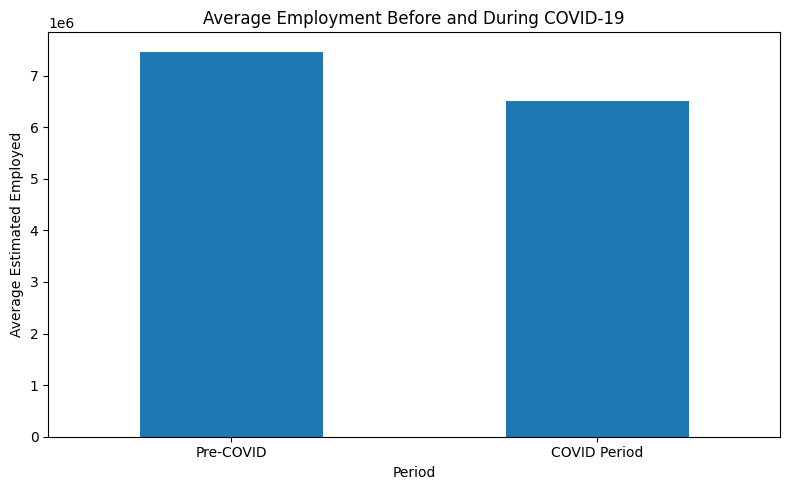

In [35]:
employment_comparison = (
    df.groupby("Period")["Estimated Employed"]
    .mean()
    .reindex(["Pre-COVID", "COVID Period"])
)

print(employment_comparison)

plt.figure(figsize=(8, 5))
employment_comparison.plot(kind="bar")

plt.title("Average Employment Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Estimated Employed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
pre_covid_employment = employment_comparison["Pre-COVID"]
covid_employment = employment_comparison["COVID Period"]

employment_change = covid_employment - pre_covid_employment

employment_percent_change = (
    employment_change / pre_covid_employment
) * 100

print(f"Average employment before COVID: {pre_covid_employment:,.0f}")
print(f"Average employment during COVID: {covid_employment:,.0f}")
print(f"Change in employment: {employment_change:,.0f}")
print(f"Percentage change in employment: {employment_percent_change:.2f}%")

Average employment before COVID: 7,466,028
Average employment during COVID: 6,517,203
Change in employment: -948,825
Percentage change in employment: -12.71%


## Key Findings

1. Urban unemployment was higher than rural unemployment, averaging approximately 13.17% compared with about 10.32% in rural areas.

2. Average unemployment increased from approximately 9.51% before COVID-19 to 17.77% during the COVID period.

3. This represents an increase of approximately 8.26 percentage points.

4. Average estimated employment declined during the COVID-19 period, supporting the evidence of a significant labour-market disruption.

5. Both rural and urban unemployment increased sharply during the early COVID-19 period, although urban unemployment generally remained higher.

6. Considerable regional variation was observed, with some regions recording substantially higher unemployment than others.

7. April recorded the highest monthly average unemployment rate in the available dataset. This is more likely associated with the COVID-19 economic shock than a normal seasonal effect.

8. Labour-force participation did not show a simple strong linear relationship with unemployment, suggesting that labour-market outcomes are influenced by multiple economic factors.

## Policy Recommendations

Based on the analysis, the following measures may help improve labour-market resilience:

- Target employment-support programmes toward regions with persistently high unemployment.
- Expand vocational, technical and digital-skills programmes.
- Strengthen social-protection systems during periods of major economic disruption.
- Provide support to small and medium-sized businesses to protect and create jobs.
- Develop different employment interventions for rural and urban populations.
- Improve real-time labour-market monitoring to identify sudden unemployment shocks earlier.

## Conclusion

This project analyzed unemployment trends in India using Python, focusing on regional differences, rural and urban patterns, labour-force participation, monthly changes and the impact of COVID-19.

The analysis identified a substantial deterioration in labour-market conditions during the COVID-19 period. Average unemployment increased from approximately 9.51% before COVID-19 to 17.77% during the COVID period, while average estimated employment declined.

Urban areas experienced higher average unemployment than rural areas, and considerable differences were also observed between regions. The sharp increase in unemployment around April and the following months demonstrates the significant disruption associated with the early COVID-19 period.

Overall, this project demonstrates how Python, data cleaning, exploratory data analysis and visualization can be used to transform labour-market data into meaningful economic and social-policy insights.

In [38]:
df.to_csv("cleaned_unemployment_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
